In [1]:
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
from files.pezw2 import pezw2
from files.ECGmake import ECGmake

Σε αυτή την άσκηση θα χρησιμοποιήσετε αρκετά μια custom συνάρτηση που ονομάζεται pezw2, η οποία τυπώνει μερικά ενδιαφέροντα γραφήματα σχετικά με μια συνάρτηση μεταφοράς $$H(z) = \frac{P(z)}{Q(z)}$$

Δείτε παρακάτω τι κάνει και πως συντάσσεται.

In [2]:
help(pezw2)

Help on function pezw2 in module files.pezw2:

pezw2(B, A)
    pezw2(B,A)
    
    Η PEZW2(B,A) σχεδιάζει
    (a) το μέτρο του H(z),
    (b) τα μηδενικά και τους πόλους (με τον μοναδιαίο κύκλο ως αναφορά),
    (c) το φάσμα πλάτους και φάσης του συστήματος,
    (d) την κρουστική απόκριση h[n] (τα πρώτα 100 δείγματα), και
    (e) την καθυστέρηση ομάδας του συστήματος.
    
    Τα B και A είναι πολυώνυμα ως προς z^-1:
    B(z): διάνυσμα που περιέχει τους συντελεστές του αριθμητή σε φθίνουσα
    σειρά δυνάμεων του z^-1
    A(z): διάνυσμα που περιέχει τους συντελεστές του παρονομαστή σε φθίνουσα
    σειρά δυνάμεων του z^-1
    
    Παραδείγματα:
    για τη συνάρτηση μεταφοράς H(z) = 1/(1-0.4z^-1), καλέστε pezw2([1], [1, -0.4]);
    για τη συνάρτηση μεταφοράς H(z) = 1/(1 - 0.6exp(jπ/2)z^-1)(1 - 0.6exp(-jπ/2)z^-1), καλέστε
    pezw2([1], np.convolve([1, 0.6*np.exp(1j*np.pi/2)], [1, 0.6*np.exp(-1j*np.pi/2)])



"Ξε-σχολιάστε" τα δυο παραδείγματα και εξετάστε τα γραφήματα ώστε να καταλάβετε περισσότερα.

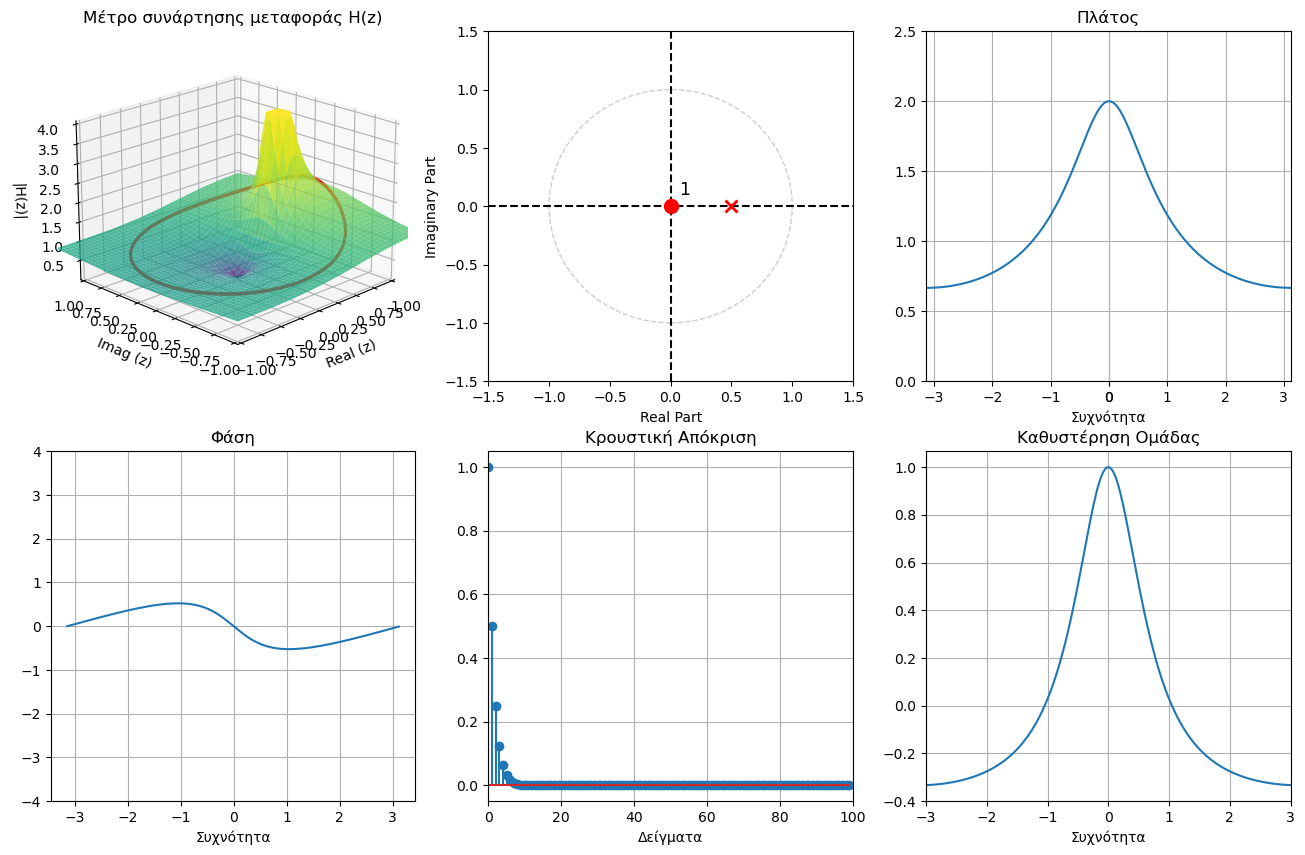

In [3]:
pezw2([1], [1, -0.5])

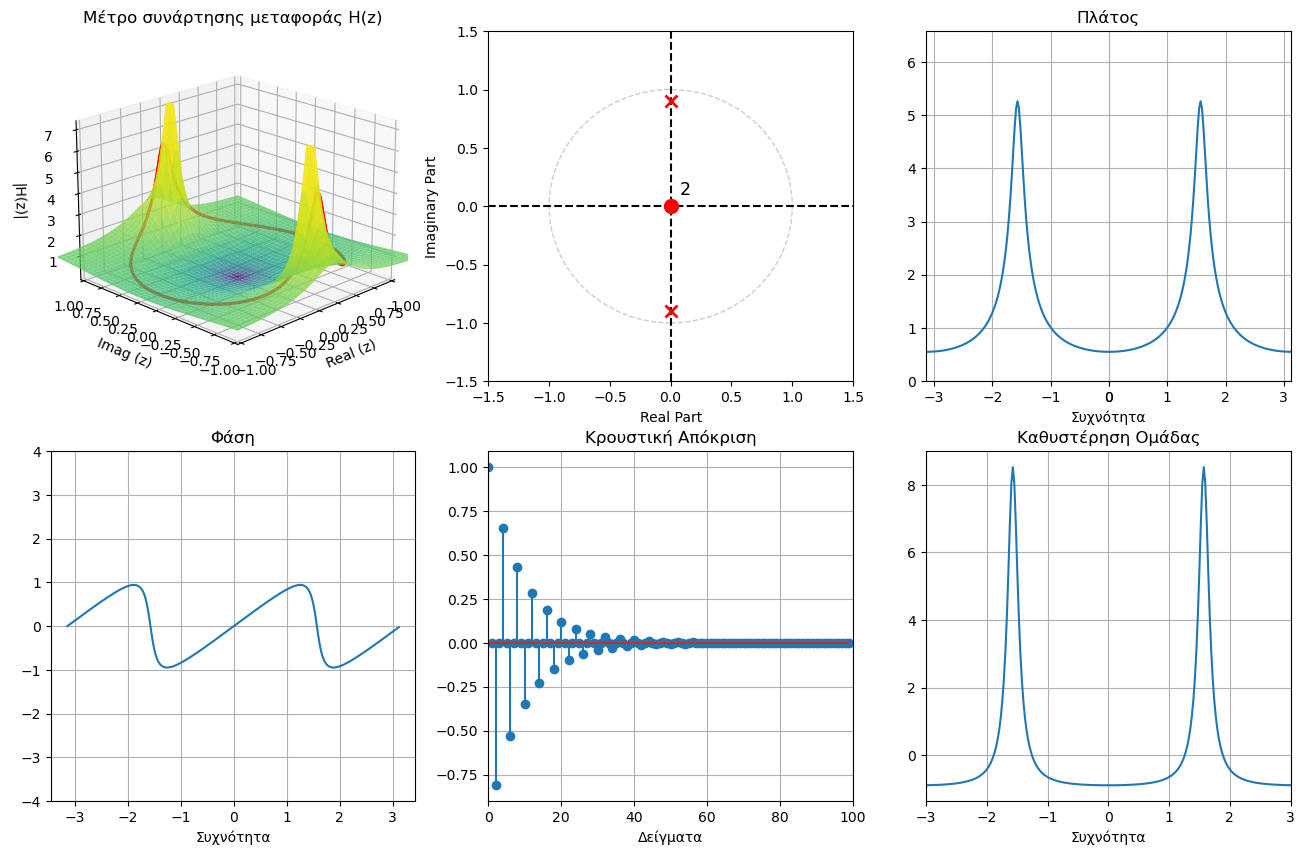

In [4]:
pezw2([1], np.convolve([1, -0.9*np.exp(1j*np.pi/2)], [1, -0.9*np.exp(-1j*np.pi/2)]))

---
---

## Άσκηση - Σχεδιασμός Notch Φίλτρων και Αποθορυβοποίηση Ηλεκτροκαρδιογραφήματος
Σε μια άσκηση προηγούμενου κεφαλαίου, κληθήκατε να αποθορυβοποιήσετε ένα σήμα φωνής από ένα ημιτονοειδή θόρυβο στα $f_0 = 400$ Hz. Το φίλτρο που φτιάξατε με απλές εξισώσεις διαφορών ήταν μέτριας ποιότητας, μια και κατέστελλε μεγάλο τμήμα των χαμηλών συχνοτήτων. Σε αυτό το εργαστήριο θα μάθετε να σχεδιάζετε πολύ καλύτερης ποιότητας φίλτρα, τα οποία λέγονται **notch filters**, ή αλλιώς, **φίλτρα αποκοπής συγκεκριμένης συχνότητας**. 

---


(α') Τα notch φίλτρα που θα σχεδιάσετε θα είναι IIR, δηλ. θα αποτελούνται τόσο από πόλους, όσο και από μηδενικά. Ένα IIR notch φίλτρο θα μηδενίζει μια μόνο συγκεκριμένη συχνότητα $\omega_0$ ενός σήματος, αλλά θα έχει σχεδόν μοναδιαία απόκριση πλάτους σε όλες τις άλλες συχνότητες, με αποτέλεσμα να μην τις αλλοιώνει σχεδόν καθόλου. Η παραπάνω πρόταση περιγράφη την προδιαγραφή του φίλτρου μας. Ας δούμε πως μπορούμε να το σχεδιάσουμε, σε βήματα.

i. Έστω ότι η επιθμητή συχνότητα που θέλουμε να αφαιρέσουμε είναι η $\omega_0 = \pi/4$. Καλέστε τη συνάρτηση ``pezw2`` βάζοντας δυο συζυγή μηδενικά στις συχνότητες $\omega_0 = \pm \pi/4$ ακριβώς επάνω στο μοναδιαίο κύκλο. Η συνάρτηση ``sig.convolve`` θα σας φανεί χρήσιμη. Εξετάστε την απόκριση πλάτους. Ικανοποιείται η προδιαγραφή του φίλτρου;

<u>**Απάντηση**</u>

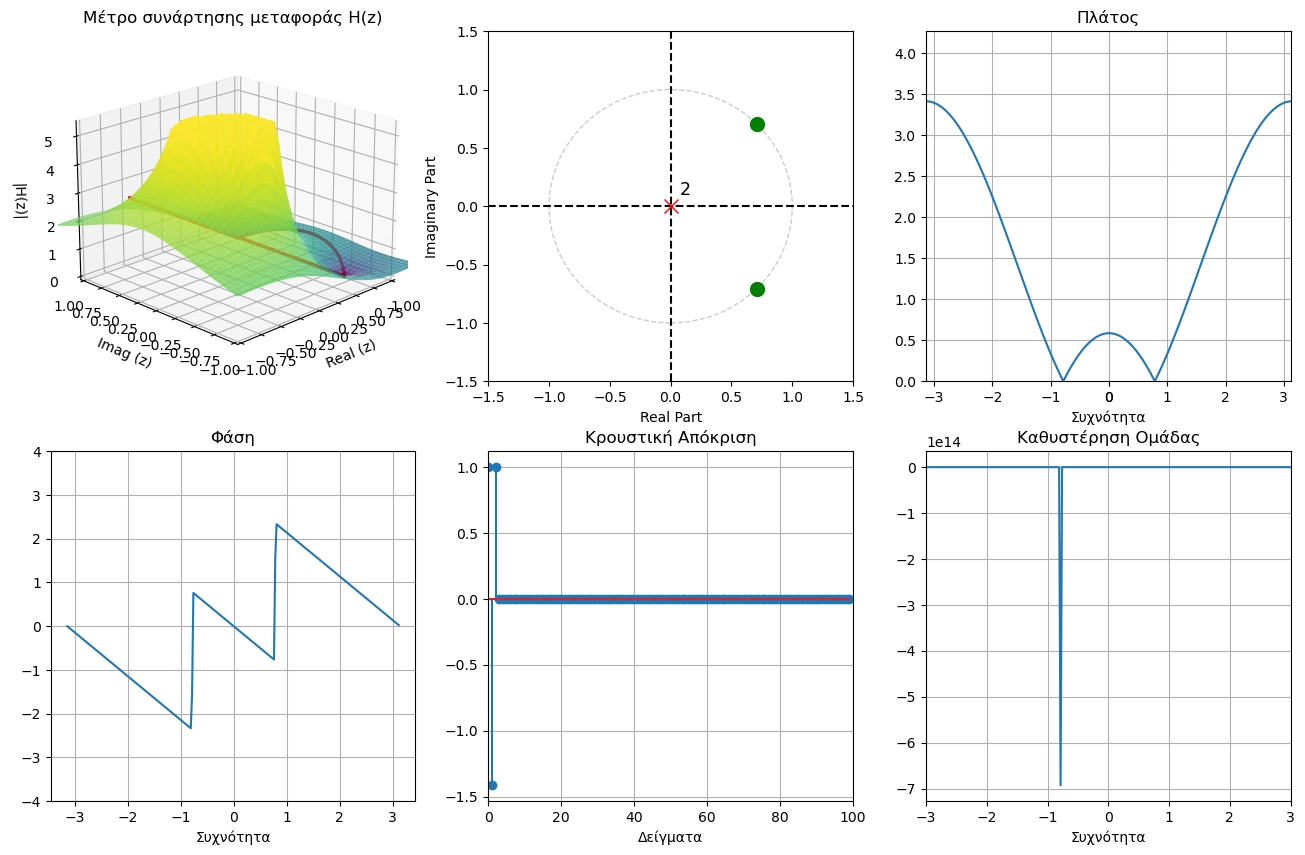

In [5]:
w0 = np.pi/4
num1 = sig.convolve([-np.exp(-1j*w0), 1], [-np.exp(1j*w0), 1])
den1 = [1]

# Η καθυστέρηση ομάδας εμφανίζει κάποιες "ασυνέπειες" - μην τις λάβετε υπ'όψη
pezw2(num1, den1)

Γράψτε εδώ το σχόλιό σας σχετικά με το φίλτρο:

Όπως βλέπουμε στο παραπάνω γράφημα, το σύστημα με $$H_{1}(z) = (1−e^{-j\frac{\pi}{4}}z^{-1})(1−e^{j\frac{\pi}{4}}z^{-1})$$ πράγματι μηδενίζει το πλάτος στις συχνότητες $\omega = \pm \pi /4$. Όμως, η απόκριση πλάτους του μεταβάλλεται, δηλαδή δεν έχει σχεδόν μοναδιαία απόκριση πλάτους πέρα από τις συχνότητες $\omega = \pm \pi/4$. Έτσι δεν ικανοποιείται η προδιαγραφή του notch φίλτρου.



ii. Όπως παρατηρείτε στο προηγούμενο γράφημα εξετάζοντας την απόκριση πλάτους, το διάστημα συχνοτήτων $(-\pi/4, \pi/4)$ έχει πολύ χαμηλό πλάτος, ενώ έξω από αυτό το πλάτος είναι μεγαλύτερο της μονάδας. Ουσιαστικά βλέπετε το FIR φίλτρο που σχεδιάσετε εσείς στο 2ο εργαστήριο. Όμως, είπαμε - και βλέπετε στο γράφημα - δεν ικανοποιεί τις προδιαγραφές του φίλτρου. Πώς θα μπορούσαμε να "σηκώσουμε" τις τιμές της απόκρισης πλάτους στο διάστημα $(-\pi/4, \pi/4)$ κοντά στη μονάδα, αλλά και να μειωθούν οι τιμές της απόκρισης πλάτους γύρω από τις συχνότητες $\omega = \pm \pi$? Φυσικά εισάγοντας κάποιους πόλους! 

Καλέστε τη συνάρτηση ``pezw2`` κρατώντας τα δυο μηδενικά που έχετε ήδη και βάζοντας επιπλέον δυο συζυγείς πόλους στις συχνότητες $\omega_0 = \pm \pi/4$ σε ακτίνα $r=0.6$ από το κέντρο του μιγαδικού επιπέδου. Η συνάρτηση ``np.convolve`` θα σας φανεί ξανά χρήσιμη. Ικανοποιείται η προδιαγραφή του φίλτρου;

<u>**Απάντηση**</u>

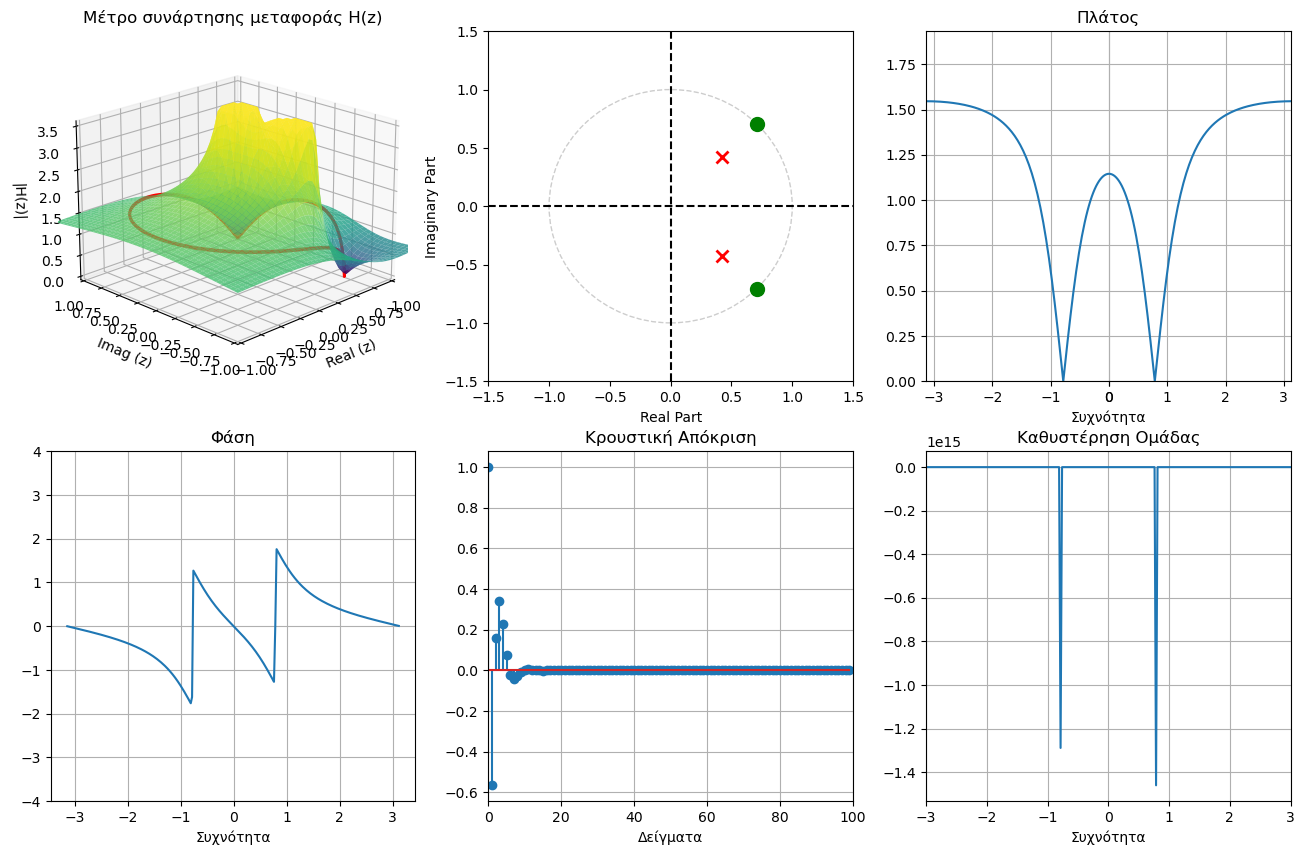

In [6]:
w0 = np.pi/4
r = 0.6

num2 = sig.convolve([-np.exp(-1j*w0), 1], [-np.exp(1j*w0), 1])
den2 = sig.convolve([1, -r*np.exp(1j*w0)], [1, -r*np.exp(-1j*w0)])

# Η καθυστέρηση ομάδας εμφανίζει κάποιες "ασυνέπειες" - μην τις λάβετε υπ'όψη
pezw2(num2, den2)

Όπως βλέπουμε στο παραπάνω γράφημα, το σύστημα με $$H_{2}(z) = \frac{(1-e^{-j\frac{\pi}{4}}z^{-1})(1- e^{j\frac{\pi}{4}}z^{-1})}{(1 - 0.6e^{-j\frac{\pi}{4}}z^{-1})(1-0.6e^{j\frac{\pi}{4}}z^{-1})}$$ μηδενίζει το πλάτος στις συχνότητες $\omega = \pm \pi /4$. Όμως, η απόκριση πλάτους του πάλι μεταβάλλεται, δηλαδή δεν έχει σχεδόν μοναδιαία απόκριση πλάτους πέρα από τις συχνότητες $\omega = \pm \pi /4$. Έτσι δεν ικανοποιείται η προδιαγραφή του notch φίλτρου. Βέβαια, σε σχέση με το προηγούμενο σύστημα, η απόκριση πλάτους του $H_{2}(z)$ φαίνεται ότι προσεγγίζει αρκετά καλύτερα την προδιαγραφή.


iii. Επαναλάβετε για $r=0.8$. Ικανοποιείται η προδιαγραφή του φίλτρου;

<u>**Απάντηση**</u>

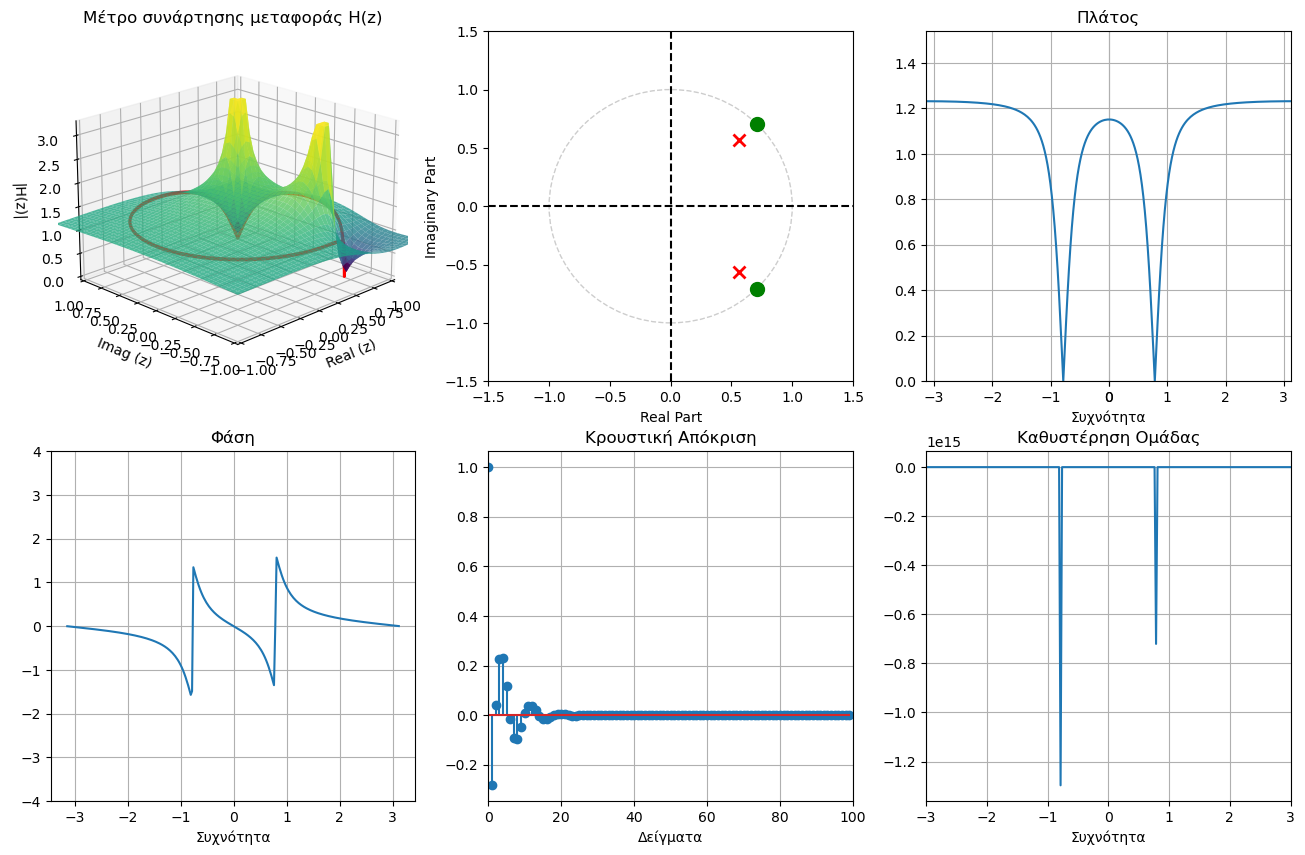

In [7]:
w0 = np.pi/4
r = 0.8

num3 = sig.convolve([-np.exp(-1j*w0), 1], [-np.exp(1j*w0), 1])
den3 = sig.convolve([1, -r*np.exp(1j*w0)], [1, -r*np.exp(-1j*w0)])

# Η καθυστέρηση ομάδας εμφανίζει κάποιες "ασυνέπειες" - μην τις λάβετε υπ'όψη
pezw2(num3, den3)

Γράψτε εδώ το σχόλιό σας σχετικά με το φίλτρο:

Όπως βλέπουμε στο παραπάνω γράφημα, και το σύστημα με $$H_{3}(z) = \frac{(1 - e^{-j\frac{\pi}{4}}z^{-1})(1 - e^{j\frac{\pi}{4}}z^{-1})}{(1 - 0.8e^{-j\frac{\pi}{4}}z^{-1})(1 - 0.8e^{j\frac{\pi}{4}}z^{-1})}$$ μηδενίζει το πλάτος στις συχνότητες $\omega = \pm \pi / 4$. Η απόκριση πλάτους του ακόμα μεταβάλλεται, αλλά πλησιάζει πολύ το να έχει σχεδόν μοναδιαία απόκριση πλάτους πέρα από τις συχνότητες $\omega = \pm \pi /4$. Δεν ικανοποιείται ακόμα πλήρως η προδιαγραφή του notch φίλτρου, αλλά είμαστε σε πολύ καλό δρόμο και υπάρχει σαφής βελτίωση σε σχέση με τα προηγούμενα συστήματα.

iv. Πειραματιστείτε και παραδώστε ΕΝΑ ακόμα γράφημα της συνάρτησης ``pezw2``, όπου οι πόλοι είναι κατάλληλα τοποθετημένοι ώστε να ικανοποιείται η προδιαγραφή του φίλτρου αρκετά καλά - δε χρειάζεται να είναι τέλεια. Ποιά τιμή του $r$ δώσατε σε αυτούς;

<u>**Απάντηση**</u>

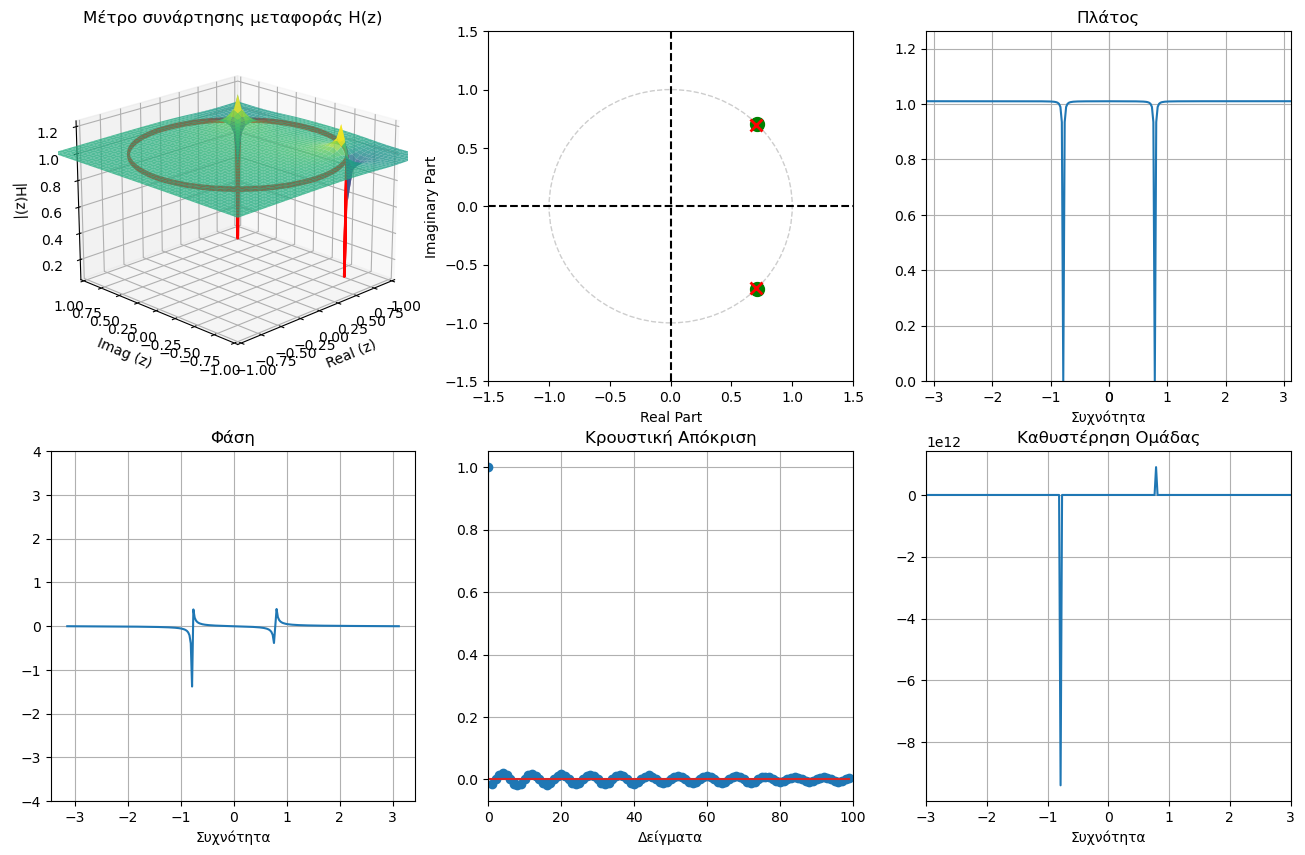

In [8]:
# subquestion a.iv)
w0 = np.pi/4
r = 0.99

num4 = sig.convolve([-np.exp(-1j*w0), 1], [-np.exp(1j*w0), 1])
den4 = sig.convolve([1, -r*np.exp(1j*w0)], [1, -r*np.exp(-1j*w0)])

# Η καθυστέρηση ομάδας εμφανίζει κάποιες "ασυνέπειες" - μην τις λάβετε υπ'όψη
pezw2(num4, den4)

Γράψτε εδώ τα σχόλιά σας σχετικά με το φίλτρο:


Από τα προηγούμενα ερωτήματα παρατηρούμε ότι όσο το $r \rightarrow , r \not = 1$, τόσο πιο κοντά φτάνουμε στην προδιαγραφή του notch φίλτρου. Η ιδανική τιμή για το $r$ r λοιπόν θα ήταν $r = 0.9999...$ . Έτσι, επιλέγουμε την τιμή $r = 0.99$. 

Όπως βλέπουμε και στο παραπάνω γράφημα, το σύστημα μας, με $$H_{4}(z) = \frac{(1- e^{-j\frac{\pi}{4}}z^{-1})(1 - e^{j\frac{\pi}{4}}z^{-1})}{(1 - 0.99e^{-j\frac{\pi}{4}}z^{-1})(1 - 0.99e^{j\frac{\pi}{4}}z^{-1})}$$ προσεγγίζει όσο καλύτερα γίνεται τις προδιαγραφές που θέσαμε. Συγκεκριμένα, στις συχνότητες $\omega = \pm \frac{\pi}{4}$, το πλάτος μηδενίζεται και η απόκριση πλάτους είναι σχεδόν μοναδιαία οπουδήποτε αλλού.

v. Υλοποιήστε ένα ημίτονο συχνότητας $\omega_0 = \pi/4$ διάρκειας $501$ δειγμάτων, ως

````python
n = [i for i in range(0, 501)]
x = [20*np.cos(w0*k) for k in n]
````


και περάστε το μέσα από το φίλτρο που υλοποιήσατε, με την εντολή ``sig.lfilter``, ώστε να επιβεβαιώσετε τη λειτουργία του. 

Περιμένετε - θεωρητικά - το φίλτρο σας να μηδενίσει εντελώς αυτό το ημίτονο και στην έξοδό του να παρουσιαστεί ένα μηδενικό σήμα. Σχεδιάστε το γράφημα (εντολή ``plt.stem``) του διακριτού σήματος πριν και μετά το φιλτράρισμα. Το φίλτρο σας μηδενίζει **εντελώς κι άμεσα** το σήμα εισόδου? Αν όχι, γιατί; Εξηγήστε.

<u>**Απάντηση**</u>

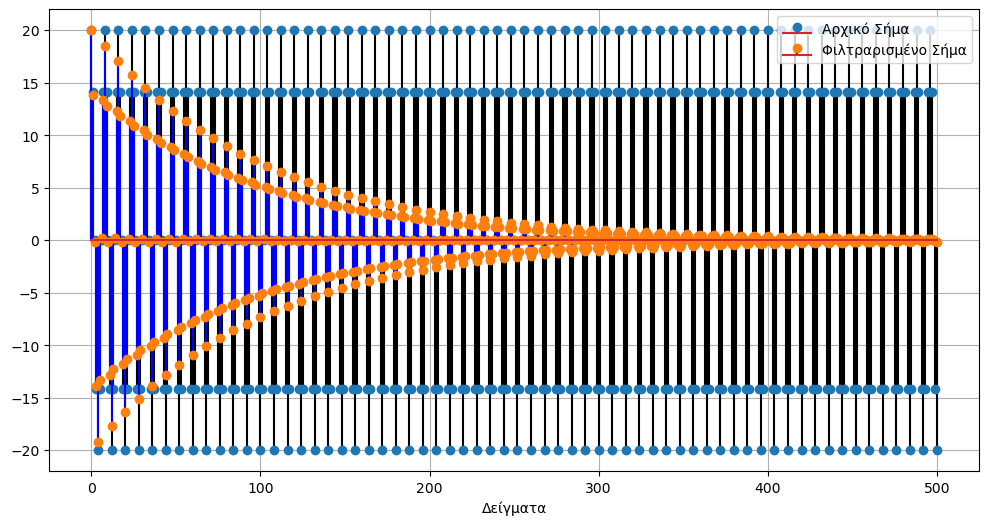

In [9]:
w0 = np.pi/4
r = 0.99
n = [i for i in range(0, 501)]
x = [20*np.cos(w0*k) for k in n]

num4 = sig.convolve([-np.exp(-1j*w0), 1], [-np.exp(1j*w0), 1])
den4 = sig.convolve([1, -r*np.exp(1j*w0)], [1, -r*np.exp(-1j*w0)])

y = sig.lfilter(num4, den4, x)

plt.figure(figsize=(12, 6))
plt.stem(n, x, linefmt='black', markerfmt='o')
plt.stem(n, y, linefmt='blue', markerfmt='o')
plt.grid(True)
plt.legend(['Αρχικό Σήμα','Φιλτραρισμένο Σήμα'], loc="upper right")
plt.xlabel('Δείγματα')
plt.show()

Γράψτε εδώ το σχόλιό σας:

Στην πράξη, όμως, παρατηρούμε το αντίθετο (όπως φαίνεται και στα παρακάτω γραφήματα)! Βλέπουμε ότι όσο μικρότερο είναι το $r$, τόσο περισσότερο/γρηγορότερα μηδενίζει το σήμα εισόδου. Αυτό ίσως οφείλεται στο γεγονός ότι όσο πιο κοντά βρίσκονται ένας πόλος και ένα μηδενικό, τόσο περισσότερο αλληλοαναιρείται η δράση τους, οπότε δεν μεταβάλλεται το πλάτος πολύ γύρω από τις συχνότητες που θέλουμε να μηδενίσουμε (καλό σημάδι), άλλα ταυτόχρονα δεν μηδενίζονται απόλυτα και οι ίδιες οι συχνότητες (αρνητικό). Βέβαια, αυτό δεν σημαίνει ότι όσο μικρότερο είναι το r, τόσο το καλύτερο! Όσο μικραίνει το $r$, πράγματι ‘μηδενίζονται περισσότερο’ οι ζητούμενες συχνότητες, αλλά αποκόπτονται περισσότερο και οι γύρω συχνότητες. Έτσι, πρέπει να επιλέγεται κατάλληλα το $r$ ανάλογα με το πρόβλημα προς επίλυση. Είναι θεμιτό όμως το $r$ να είναι κοντά στο $1$. Το φαινόμενο αυτό μας θύμισε την ξαφνική είσοδο σε ΓΧΑ συστήματα, στην οποία η έξοδος χωρίζεται σε απόκριση σταθερής κατάστασης (steady state response: ακριβώς το αποτέλεσμα που θα λαμβάναμε) και μεταβατική απόκριση (transient response: το «πόσο απέχει» η έξοδός μας από το αποτέλεσμα). Συγκεκριμένα, η κρουστική απόκριση είναι IIR και ισχύει $\lim_{n \rightarrow \infty} h[n] = 0$, η μεταβατική απόκριση δεν εξαφανίζεται ακαριαία, αλλά φθίνει σταδιακά στο 0, ακριβώς όπως συμβαίνει στην περίπτωση μας.

---

(β') Τώρα που είστε experts :) στη σχεδίαση notch φίλτρων, δείξτε τις ικανότητές σας σε ένα πραγματικό πρόβλημα! 


Σίγουρα γνωρίζετε το πολύ συνηθισμένο τεστ που κάνουμε για την καρδιά μας, το περίφημο Ηλεκτροκαρδιογράφημα (ECG). Το ECG καταγράφει την ηλεκτρική δραστηριότητα που αλλάζει κατά τη διάρκεια ενός καρδιακού κύκλου. 

Η καταγραφή γίνεται - ενημερωτικά - ως εξής: ο καρδιολόγος τοποθετεί μεταλλικά ηλεκτρόδια σε διάφορες θέσεις στο σώμα, ώστε να "πιάσει" αυτά τα καρδιακά ηλεκτρικά σήματα. Δυστυχώς, τα ηλεκτρόδια καταγράφουν επίσης σήματα από άλλες ηλεκτρικές πηγές, συνήθως αρμονικές στα $50$ Hz, που είναι η συχνότητα των συσκευών που έχουμε στα σπίτι μας στην Ελλάδα (σε άλλες χώρες, η συχνότητα λειτουργίας τους είναι $60$ Hz). Σκοπός της άσκησης είναι να αφαιρέσετε μια τέτοια πραγματική ημιτονοειδής παρεμβολή με χρήση notch φίλτρων από ένα σήμα ηλεκτροκαρδιογραφήματος, ώστε να παραδώσετε στο γιατρό ένα καθαρό σήμα προς διάγνωση.

Το notch φίλτρο θα είναι της μορφής που είδατε νωρίτερα, δηλ. θα περιέχει 2 συζυγή μηδενικά ακριβώς πάνω στο μοναδιαίο κύκλο και 2 συζυγείς πόλους πολύ κοντά του, σε κατάλληλη συχνότητα. Άρα η συνάρτηση μεταφοράς του φίλτρου θα είναι
$$H(z) = \frac{(1 - e^{j\theta}z^{-1})(1 - e^{-j\theta}z^{-1})}{(1 - re^{j\theta}z^{-1})(1 - re^{-j\theta}z^{-1})}$$
με $\theta$ να είναι η γωνία θέσης των πόλων και μηδενικών, και $r$ η ακτίνα των πόλων.

Το ηλεκτροκαρδιογράφημα θα το παράξετε με την κλήση της συνάρτησης ``ECGmake`` που σας δίνεται. Η συνάρτηση αυτή διαβάζει δεδομένα από ένα αρχείο ``ECG.mat``, που επίσης σας δίνεται. Το ηλεκτροκαρδιογράφημα θα είναι διαφορετικό για κάθε 4ψήφιο αριθμό που του δίνετε, αφού η κλήση της ``ECGmake`` δέχεται ως όρισμα έναν τέτοιο αριθμό. Για την ακρίβεια, η συνάρτηση αυτή συντάσσεται ως 

```python
def ECGmake(rnstring):
# ecgsig = διανυσμα των δειγμάτων του σήματος σε fs δείγματα/δευτερόλεπτο
# fint = συχνότητα παρεμβολής σε Hz
# rnstring = 4-ψήφιος αριθμός : e.g., ’1367’ or ’3646’
#
#
    return ecgsig, fs, fint
```

Ακολουθήστε τα παρακάτω βήματα:

i. Καλέστε τη συνάρτηση ``ECGmake`` και καταγράψτε/παρατηρήστε τις τιμές για τη συχνότητα δειγματοληψίας $f_s$ και για τη συχνότητα ημιτονοειδούς παρεμβολής $f_{int}$, την οποία θέλετε να αφαιρέσετε.

<u>**Απάντηση**</u>

In [10]:
ecgsig, fs, fint = ECGmake('1367')
print(fint[0])

[114.00467763]


Το ηλεκτροκαρδιογράφημα που παράξαμε έχει συχνότητα δειγματοληψίας $f_{s} = 8000$ Hz και συχνότητα ημιτονοειδούς παρεμβολής $f_{int}$ Hz όπως παραπάνω.

ii. Σχεδιάστε στο χαρτί το notch φίλτρο σας τοποθετώντας κατάλληλα πόλους και μηδενικά στο μιγαδικό επίπεδο. Εξηγήστε την επιλογή της συχνότητας $\omega_{int}$ που κάνατε για τους πόλους και τα μηδενικά σας, καθώς και την τιμή της ακτίνας $r$ για τους πόλους σας. Γράψτε τη συνάρτηση μεταφοράς $H(z)$ στην οποία καταλήξατε.

<u>**Απάντηση**</u>

Γνωρίζουμε ότι το notch φίλτρο θα είναι της μορφής:
$$H(z) = \frac{(1-e^{j\theta}z^{-1})(1-e^{-j\theta}z^{-1})}{(1-re^{j\theta}z^{-1})(1-re^{-j\theta}z^{-1})}$$
Ακόμα, ξέρουμε ότι (**τα παρακάτω είναι ενδεικτικά, θα διαφέρουν ανά φοιτητή**):

$$\omega_{int} = 2\pi \frac{f_{int}}{f_{s}} \simeq 2\pi \frac{58.43}{8000} \simeq 2\pi 0.007304 \Rightarrow \omega_{int} = 0.015\pi$$

Ως $r$ επιλέξαμε την τιμή $r = 0.99$, καθώς είναι κοντά στο $1$ (σύμφωνα με τα πορίσματα που είχαμε από το
(α) ερώτημα). Έτσι, το φίλτρο μας είναι το:

$$H(z) = \frac{(1 - e^{j0.015\pi}z^{-1})(1 - e^{-j0.015\pi}z^{-1})}{(1 - 0.99e^{j0.015\pi}z^{-1})(1 - 0.99e^{-j0.015\pi}z^{-1})}$$




iii. Καλέστε τη συνάρτηση ``pezw2`` και βεβαιωθείτε ότι το φίλτρο σας έχει τις προδιαγραφές που πρέπει.

<u>**Απάντηση**</u>

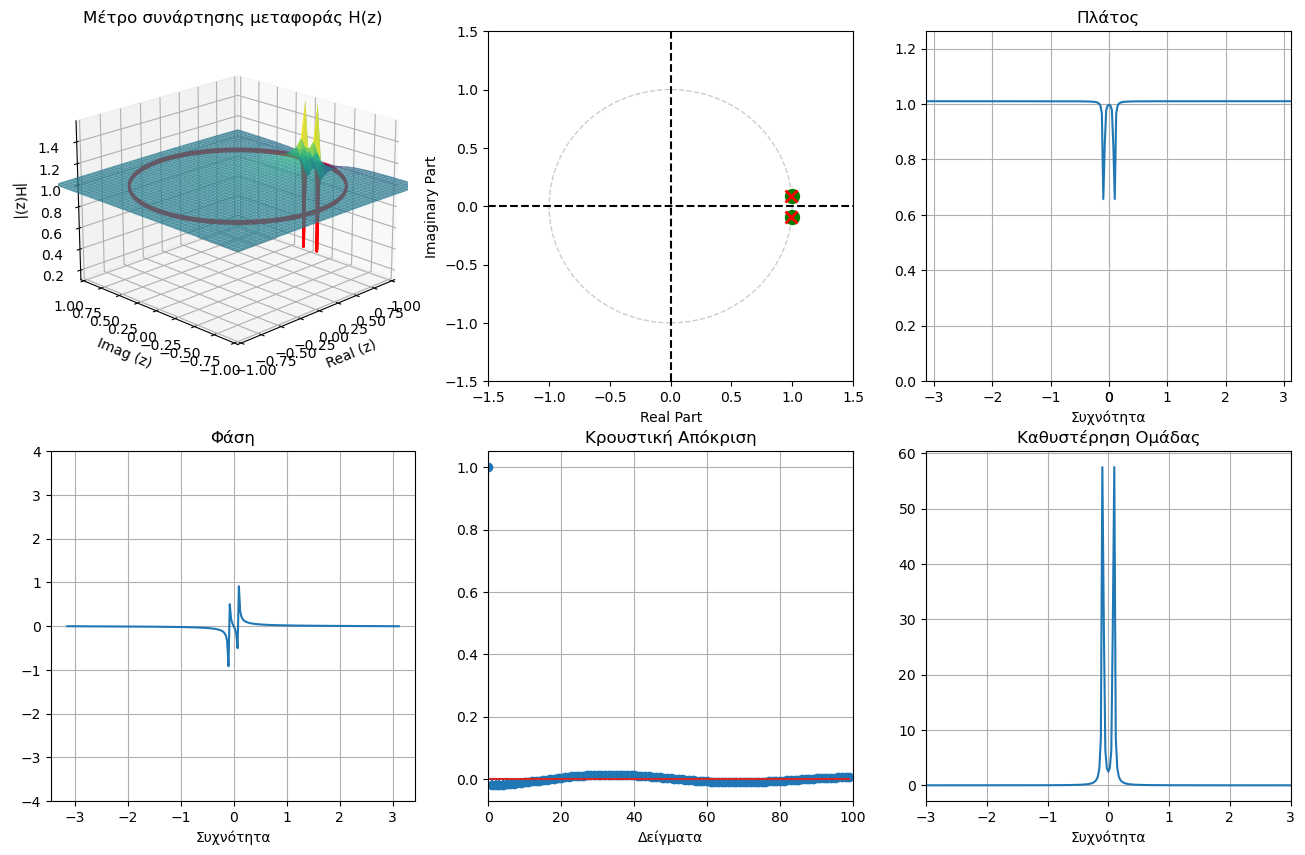

In [11]:
Wint = 2*np.pi*fint[0]/fs

r = 0.99
num = sig.convolve([-np.exp(-1j*Wint[0]), 1], [-np.exp(1j*Wint[0]), 1])
den = sig.convolve([1, -r*np.exp(-1j*Wint[0])], [1, -r*np.exp(1j*Wint[0])])

pezw2(num, den)

Θεωρούμε ότι το φίλτρο μας έχει τις προδιαγραφές που χρειάζεται, καθώς η απόκριση πλάτους σχεδόν
μηδενίζεται για $\omega = \pm \omega_{int}$ και για τις υπόλοιπες συχνότητες είναι σχεδόν μοναδιαία

iv. Εφαρμόστε το φίλτρο σας (εντολή ``sig.lfilter``) στο σήμα ecgsig που σας επέστρεψε η ``ECGmake``. Σχεδιάστε και παραδώστε (εντολή ``plt.plot``) το σήμα ηλεκτροκαρδιογραφήματος πριν και μετά το φιλτράρισμα. Αν τα καταφέρετε σωστά, θα πάρετε ένα ηλεκτροκαρδιογράφημα όπως στο Σχήμα 1.

<center>
<div>
<img src="./files/clearECG.png" width="1000"/>
</div>
Σχήμα 1: Ηλεκτροκαρδιογράφημα μετά την αφαίρεση του θορύβου
</center>

<u>**Απάντηση**</u>

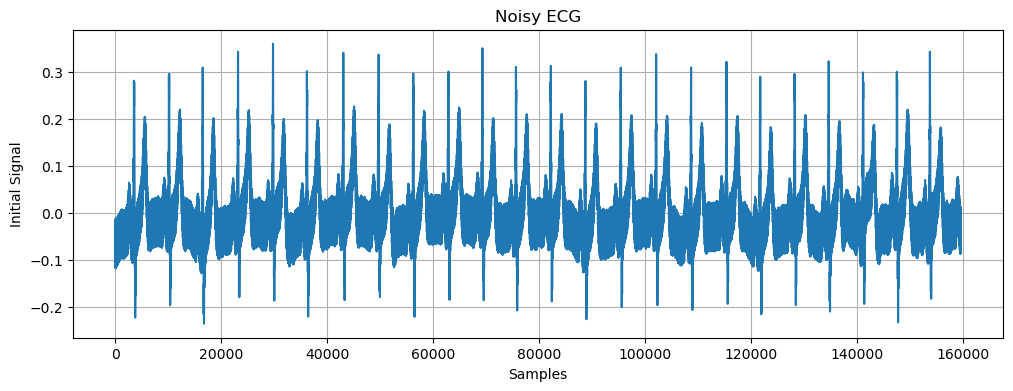

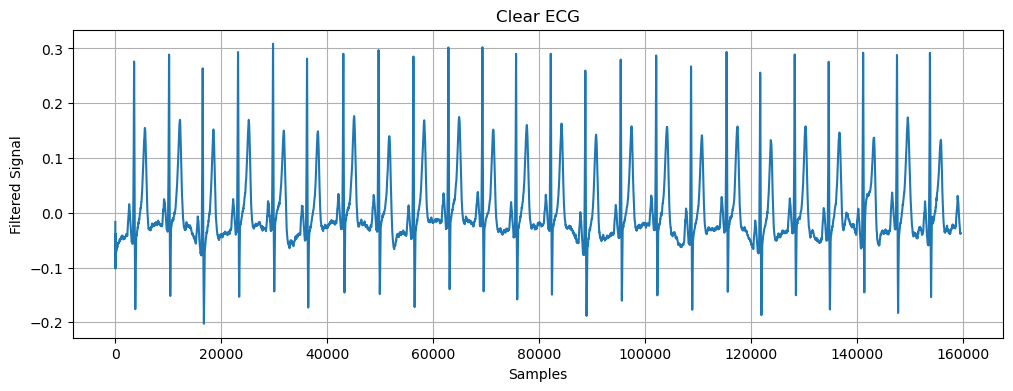

In [12]:
ECG = ecgsig.T[0]
y = sig.lfilter(num, den, ECG)

plt.figure(figsize=(12, 4))
plt.title('Noisy ECG')
plt.plot(ECG)
plt.grid(True)
plt.xlabel('Samples')
plt.ylabel('Initial Signal')

plt.figure(figsize=(12, 4))
plt.title('Clear ECG')
plt.plot(y)
plt.grid(True)
plt.xlabel('Samples')
plt.ylabel('Filtered Signal')

plt.show()

---
---